In [1]:
import pyFAI
import h5py, hdf5plugin
import numpy as np
import matplotlib.pyplot as plt
import pyFAI.opencl as cl

In [2]:
ai = pyFAI.load("/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/process/LaB6_35keV_599p927mm.poni")

In [3]:
path_scans = '/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/raw/xrd_ct_overview/'
filename = 'scan-0339_pilatus.h5'

projection_idx = 0
with h5py.File(path_scans + filename, 'r') as f:
    dataset = f['entry/instrument/pilatus/data']
    data = dataset[362 * projection_idx : 362 * projection_idx + 362]

In [4]:
print(cl.ocl)

OpenCL devices:
[0] NVIDIA CUDA: (0,0) Tesla V100-PCIE-16GB


In [5]:
for i in range(1):

    res = ai.integrate2d(
        data[150],
        npt_rad=150,
        npt_azim=360,
        radial_range=(8.0, 40.0),
        method=("no", "csr", "opencl"),
    )


intensity = res.intensity     # shape (npt_azim, npt_rad)
rad = res.radial        # 1D array
chi = res.azimuthal           # 1D array


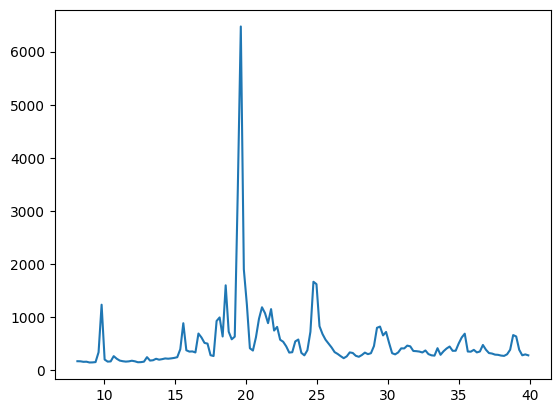

In [6]:
plt.plot(rad, intensity.sum(axis=0))

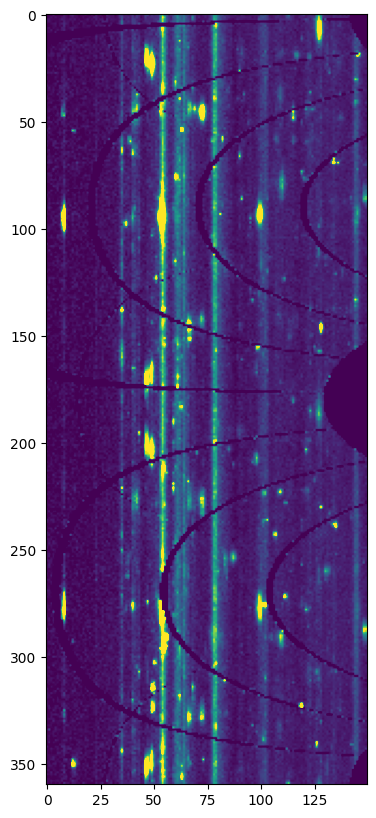

In [7]:
plt.figure(figsize=(20,10))
plt.imshow(intensity)
plt.clim([np.quantile(intensity,q=0.1),np.quantile(intensity, q=0.99) ])
plt.show()

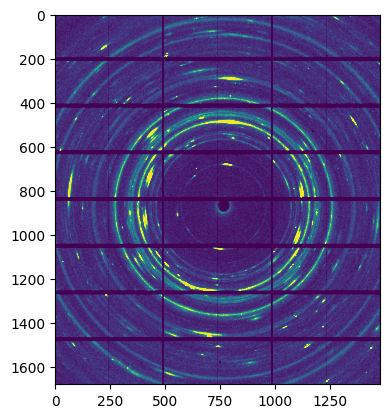

In [8]:
plt.imshow(data[150])
plt.clim([np.quantile(data[150],q=0.1),np.quantile(data[150], q=0.99) ])
plt.show()

In [9]:
import pyFAI
import h5py, hdf5plugin
import numpy as np
import yaml
import argparse 

config = '/zhome/71/c/146676/texture_tomography/configs/aluminum_config_single.yaml'

# -------------------------
# Load YAML configuration
# -------------------------
with open(config, 'r') as f:
    cfg = yaml.safe_load(f)

poni_path = cfg['poni_path']
datapath = cfg['datapath']
diffraction_files = cfg['diffraction_files']
N_rot = 3000 # Hardcoded on purpose
N_trans_total = cfg['Nx']
N_theta = cfg['N_theta']
N_chi = cfg['N_chi']

output_file = cfg["integrated_file"]
# Batching: Choose the number of detecotr images to integrate at a time. 3000 should be divisible by it
batch_size = 300

In [16]:
i_h5 = -1
with h5py.File(datapath + diffraction_files[i_h5], 'r') as f:
    dataset = f['entry/instrument/pilatus/data']
    N_det, My, Mx = dataset.shape
    data = dataset[4000 : 4000 + batch_size]


In [23]:
(17-3)*10+(11-3)

148

In [20]:
print(3003*11)

33033


In [55]:
ai = pyFAI.load(poni_path)


In [56]:
def two_theta_to_q(two_theta, wavelength):
    # PyFAI uses 1/nm for q. Poni wavelength is in m
    return (4*np.pi/wavelength) * np.sin(0.5 * two_theta)

def q_to_two_theta(q, wavelength):
    # PyFAI uses 1/nm for q. Poni wavelength is in m
    return 2 * np.arcsin(q * wavelength / (4*np.pi))


In [57]:
width_two_theta = 0.01
peaks_two_theta = np.array([0.15253486, 0.17618918, 0.24949356 , 0.29284422, 0.38588877])
q_lower = two_theta_to_q(peaks_two_theta-width_two_theta, wavelength=ai.wavelength*1e9)
q_upper = two_theta_to_q(peaks_two_theta+width_two_theta, wavelength=ai.wavelength*1e9)
q_min = q_lower.min()
q_max = q_upper.max()
N_chi = 4*360
N_theta = 50
N_rings = 5
I_rings = np.zeros((N_chi, N_rings), dtype=np.float32)

mask_list = []
delta_q = (q_max-q_min)/(N_theta)
q = np.linspace(q_min+delta_q/2, q_max-delta_q/2, N_theta)

for i_ring in range(N_rings):
    mask = (q >= q_lower[i_ring]) & (q < q_upper[i_ring])
    mask_list.append(mask)



In [68]:

for i in range(batch_size):
    res = ai.integrate2d(
        data[i],
        npt_rad=N_theta,
        npt_azim=N_chi,
        radial_range=(q_min, q_max),
        method=("no", "csr", "opencl"),
        )
    I = res.intensity

    for i_ring in range(N_rings):
        I_rings[:,i_ring] = I[:,mask_list[i_ring]].sum(axis=1)




In [69]:

for i in range(batch_size):
    res = ai.integrate2d(
    data[i],
    npt_rad=N_theta,
    npt_azim=N_chi,
    radial_range=(q_min, q_max),
    method=("no", "csr", "opencl"),
        )
    I = res.intensity



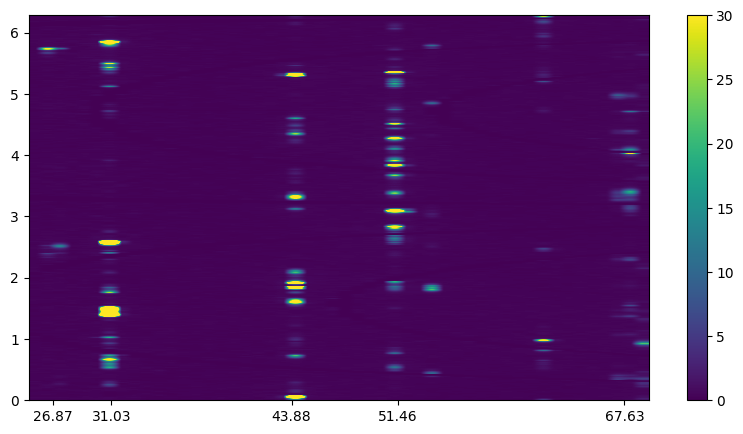

In [60]:
plt.figure(figsize=(10,5))
peaks_q = two_theta_to_q(peaks_two_theta, wavelength=ai.wavelength*1e9)
plt.xticks(peaks_q)
plt.imshow(I, extent=(q_min,q_max,0, 2*np.pi), aspect='auto')
plt.clim([0,30])
plt.colorbar()

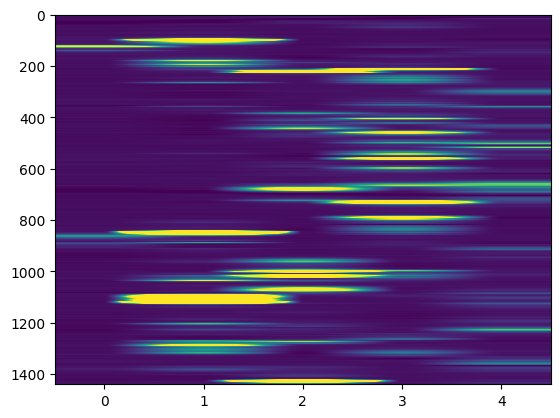

In [61]:
plt.imshow(I_rings, aspect='auto', interpolation=None)
plt.clim([0,30])

In [2]:
from multiprocessing import Pool
### Test whethe the integration is done correctly...
datapath_ = '/dtu/3d-imaging-center/projects/2025_QIM_BlackBeauty/raw_data_extern/raw_data_aluminum_rod/'


N_workers = 16  # adjust to match available CPUs

# --- Get list of dataset keys (exclude metadata) ---
filename = datapath_ + 'pilatus_integrated_re_anglemean_x3_4.h5'
with h5py.File(filename, 'r') as f:
    keys = [k for k in f.keys() if k != 'two_theta']

    keys = sorted(keys, key=lambda x: int(x))
    keys = keys[::]

with h5py.File(filename, 'r') as f:
    two_theta = f['two_theta'][:]

N_theta = len(two_theta)

# --- Worker function ---
def load_single(key):
    with h5py.File(filename, 'r') as f:
        arr = f[key][...]
    return arr

with Pool(processes=N_workers) as pool:
    data_list = pool.map(load_single, keys)

all_data = np.stack(data_list,axis=0)
all_data_reshaped = all_data.reshape((500, 148, 180*37))

In [4]:
import yaml
config_path = "configs/aluminum_config_single.yaml"

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)
datapath = cfg["datapath"]
filename_integrated = cfg["integrated_file"]
filename = datapath + filename_integrated

with h5py.File(filename, "r") as f:
    dset = f["I"]
    arr = np.empty(dset.shape, dtype=dset.dtype)
    dset.read_direct(arr)

In [8]:
print(all_data.shape, arr.shape)

(500, 148, 180, 37) (3000, 148, 180, 5)


In [20]:
all_data2 = np.concatenate([all_data[:,:,90:], all_data[:,:,:90]], axis=2)

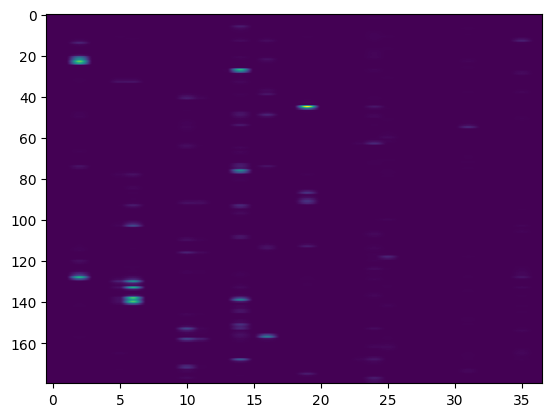

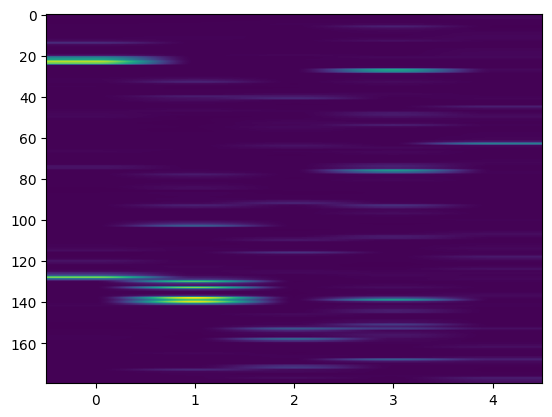

In [24]:
plt.imshow(all_data2[50,110], aspect='auto')
plt.show()

plt.imshow(arr[300:306,110].sum(axis=0), aspect='auto')
plt.show()